<a href="https://colab.research.google.com/github/thesmolbeann/ai-lab/blob/main/cartpole.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial and Sample Code for Balancing a Pole on a Cart

## Installing dependencies:

In [6]:
!apt-get install -y xvfb python-opengl > /dev/null 2>&1
!pip install gym pyvirtualdisplay > /dev/null 2>&1
!pip install gym pyvirtualdisplay > /dev/null 2>&1
!apt-get install -y xvfb python-opengl ffmpeg > /dev/null 2>&1
!pip install gym[classic_control]
!apt-get update > /dev/null 2>&1
!apt-get install cmake > /dev/null 2>&1
!pip install --upgrade setuptools 2>&1
!pip install ez_setup > /dev/null 2>&1

  Using cached pygame-2.1.0.tar.gz (5.8 MB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


## Importing dependencies and define helper functions

In [7]:
import gym
from gym import logger as gymlogger
from gym.wrappers import RecordVideo
gymlogger.set_level(40) #error only
import tensorflow as tf
import numpy as np
import random
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import math
import glob
import io
import base64
from IPython.display import HTML
from IPython import display as ipythondisplay
import time

def show_video():
  mp4list = glob.glob('video/*.mp4')
  if len(mp4list) > 0:
    mp4 = mp4list[0]
    video = io.open(mp4, 'r+b').read()
    encoded = base64.b64encode(video)
    ipythondisplay.display(HTML(data='''<video alt="test" autoplay
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
  else:
    print("Could not find video")

## Tutorial: Loading CartPole environment

In [8]:
env = gym.make("CartPole-v1")

We can check the action and observation space of this environment. Discrete(2) means that there are two valid discrete actions: 0 & 1.

In [9]:
print(env.action_space)

Discrete(2)


The observation space is given below. The first two arrays define the min and max values of the 4 observed values, corresponding to cart position, velocity and pole angle, angular velocity.

In [10]:
print(env.observation_space)

Box([-4.8000002e+00 -3.4028235e+38 -4.1887903e-01 -3.4028235e+38], [4.8000002e+00 3.4028235e+38 4.1887903e-01 3.4028235e+38], (4,), float32)


We call each round of the pole-balancing game an "episode". At the start of each episode, make sure the environment is reset, which chooses a random initial state, e.g., pole slightly tilted to the right. This initialization can be achieved by the code below, which returns the observation of the initial state.

In [13]:
observation = env.reset()
print("Initial observations:", observation)

Initial observations: [ 0.02147494  0.03965789  0.01837894 -0.03791385]


For the CartPole environment, there are two possible actions: 0 for pushing to the left and 1 for pushing to the right. For example, we can push the cart to the left using code below, which returns the new observation, the current reward, an indicator of whether the game ends, and some additional information (not used in this project). For CartPole, the game ends when the pole is significantly tilted or you manage to balance the pole for 500 steps. You get exactly 1 reward for each step before the game ends (i.e., max cumulative reward is 500).

In [14]:
observation, reward, done, info = env.step(0)
print("New observations after choosing action 0:", observation)
print("Reward for this step:", reward)
print("Is this round done?", done)

New observations after choosing action 0: [ 0.0222681  -0.15572272  0.01762066  0.26051068]
Reward for this step: 1.0
Is this round done? False


Now we can play a full round of the game using a naive strategy (always choosing action 0), and show the cumulative reward in the round. Note that reward returned by env.step(*) corresponds to the reward for current step. So we have to accumulate the reward for each step. Clearly, the naive strategy performs poorly by surviving only a dozen of steps.

In [15]:
observation = env.reset()
cumulative_reward = 0
done = False
while not done:
    observation, reward, done, info = env.step(0)
    cumulative_reward += reward
print("Cumulative reward for this round:", cumulative_reward)

Cumulative reward for this round: 8.0


## Task 1: Development of an RL agent

An example of a naive agent is given below, which randomly chooses an action regardless of the observation:

In [16]:
def rand_policy_agent(observation):
    return random.randint(0, 1)

For Task 1, we can show the observation and chosen action below:

In [17]:
observation = env.reset()
action = rand_policy_agent(observation)
print("Observation:", observation)
print("Chosen action:", action)

Observation: [ 0.03856493 -0.04689375  0.04779433  0.01633786]
Chosen action: 1


Training the RL Agent using Q-Learning:

1. Q-Learning Variables and Formula

Deciding on parameter values:
- low learning rate (0.1)
  agent makes small updates to Q-values (gradual refinement) to avoid drastic mistakes. since cartpole is a simple environment, a lower learning rate ensures the agent learns progressively so it adjusts its actions without diverging too much.

- discount factor closer to 1 (0.95)
  at this value, it makes the agent consider long-term rewards. cartpole requires medium-long term thinking to keep it balanced (it is not just the current state that affects the balance in long run).

- episodes (30,000)
  at first episodes=15000 was used, however, the average reward from that set of training was ~180, which is not good enough. hence, i doubled the training sets quantity for greater revision of Q-values for better decision making.

In [42]:
# Q-Learning Variables
learning_rate = 0.1
discount = 0.95
episodes = 30000

total = 0
total_reward = 0
prior_reward = 0

# discretizing the continuous environment
Observation = [30, 30, 50, 50]
np_array_win_size = np.array([0.25, 0.25, 0.01, 0.1])

# 100% exploration (explore all options at the beginning)
epsilon = 1

# rate of adjustment of above epsilon value
epsilon_decay_value = 0.99995

2. Setting up Q-Table

In [43]:
q_table = np.random.uniform(low=0, high=1, size=(Observation + [env.action_space.n]))
q_table.shape

(30, 30, 50, 50, 2)

3. Set up method to return discrete states from a continuous environment (Q-Learning trains on discrete states)

In [44]:
def get_discrete_state(state):
    discrete_state = state/np_array_win_size+ np.array([15,10,1,10])
    return tuple(discrete_state.astype(int))

4. Training the Q-Learning Agent
    
    a. choosing the right action:
    - epsilon = 1 at beginning --> high probability of choosing action (0/1 aka L/R) randomly
    - as epsilon decays and Q-table gets filled, agent starts to rely more on best possible action according to Q-Table
    - eventually, all chosen action is made after referencing Q-Table rather than random state

In [45]:
def train_RLagent(EPISODES, DISCOUNT, LEARNING_RATE):
    global epsilon, total_reward, prior_reward  # Ensure these are accessible within the function

    rewards_log = []  # Store rewards for post-training analysis

    for episode in range(1, EPISODES + 1):  # Start from 1 for cleaner logs
        discrete_state = get_discrete_state(env.reset())
        done = False
        episode_reward = 0

        # Logging milestone
        if episode % 2000 == 0:
            print(f"Starting Episode {episode}/{EPISODES}")

        while not done:
            if np.random.random() > epsilon:
                action = np.argmax(q_table[discrete_state])
            else:
                action = np.random.randint(0, env.action_space.n)

            new_state, reward, done, _ = env.step(action)
            episode_reward += reward
            new_discrete_state = get_discrete_state(new_state)

            # Render every 2000 episodes for visualization
            if episode % 2000 == 0:
                env.render()

            if not done:
                max_future_q = np.max(q_table[new_discrete_state])
                current_q = q_table[discrete_state + (action,)]
                new_q = (1 - LEARNING_RATE) * current_q + LEARNING_RATE * (reward + DISCOUNT * max_future_q)
                q_table[discrete_state + (action,)] = new_q

            discrete_state = new_discrete_state

        # Store rewards for analysis
        rewards_log.append(episode_reward)
        total_reward += episode_reward
        prior_reward = episode_reward

        # Epsilon Decay (Reduce exploration as learning progresses)
        if epsilon > 0.05 and episode > 10000:
            if episode_reward > prior_reward:
                epsilon = math.pow(epsilon_decay_value, episode - 10000)
                if episode % 500 == 0:
                    print(f"Episode {episode}: Epsilon adjusted to {epsilon:.6f}")

        # Print performance metrics every 1000 episodes
        if episode % 1000 == 0:
            avg_reward = total_reward / 1000
            print(f"[{episode}/{EPISODES}] Avg Reward: {avg_reward:.2f}")
            total_reward = 0  # Reset counter for next interval

    return rewards_log  # Return logged rewards for visualization

In [46]:
train_RLagent(episodes, discount, learning_rate)

[1000/30000] Avg Reward: 21.68
Starting Episode 2000/30000
[2000/30000] Avg Reward: 22.96
[3000/30000] Avg Reward: 21.88
Starting Episode 4000/30000
[4000/30000] Avg Reward: 22.99
[5000/30000] Avg Reward: 22.52
Starting Episode 6000/30000
[6000/30000] Avg Reward: 22.40
[7000/30000] Avg Reward: 21.93
Starting Episode 8000/30000
[8000/30000] Avg Reward: 22.83
[9000/30000] Avg Reward: 22.68
Starting Episode 10000/30000
[10000/30000] Avg Reward: 21.76
[11000/30000] Avg Reward: 21.31
Starting Episode 12000/30000
[12000/30000] Avg Reward: 22.80
[13000/30000] Avg Reward: 22.08
Starting Episode 14000/30000
[14000/30000] Avg Reward: 22.01
[15000/30000] Avg Reward: 22.20
Starting Episode 16000/30000
[16000/30000] Avg Reward: 22.27
[17000/30000] Avg Reward: 22.39
Starting Episode 18000/30000
[18000/30000] Avg Reward: 22.34
[19000/30000] Avg Reward: 22.39
Starting Episode 20000/30000
[20000/30000] Avg Reward: 22.60
[21000/30000] Avg Reward: 22.47
Starting Episode 22000/30000
[22000/30000] Avg Rewa

[12.0,
 33.0,
 21.0,
 17.0,
 18.0,
 11.0,
 13.0,
 17.0,
 21.0,
 16.0,
 56.0,
 17.0,
 36.0,
 11.0,
 15.0,
 33.0,
 21.0,
 43.0,
 16.0,
 17.0,
 13.0,
 12.0,
 18.0,
 12.0,
 9.0,
 12.0,
 16.0,
 30.0,
 36.0,
 21.0,
 36.0,
 17.0,
 27.0,
 37.0,
 18.0,
 20.0,
 21.0,
 30.0,
 13.0,
 15.0,
 21.0,
 25.0,
 70.0,
 14.0,
 17.0,
 22.0,
 13.0,
 12.0,
 29.0,
 27.0,
 12.0,
 40.0,
 16.0,
 20.0,
 14.0,
 11.0,
 12.0,
 10.0,
 15.0,
 10.0,
 22.0,
 18.0,
 44.0,
 12.0,
 40.0,
 11.0,
 29.0,
 33.0,
 14.0,
 13.0,
 22.0,
 17.0,
 44.0,
 23.0,
 34.0,
 15.0,
 11.0,
 31.0,
 22.0,
 71.0,
 10.0,
 25.0,
 15.0,
 62.0,
 10.0,
 9.0,
 11.0,
 44.0,
 24.0,
 16.0,
 32.0,
 25.0,
 12.0,
 12.0,
 39.0,
 17.0,
 24.0,
 18.0,
 24.0,
 25.0,
 39.0,
 26.0,
 39.0,
 30.0,
 15.0,
 12.0,
 24.0,
 12.0,
 19.0,
 16.0,
 18.0,
 32.0,
 19.0,
 12.0,
 16.0,
 18.0,
 36.0,
 50.0,
 46.0,
 16.0,
 16.0,
 22.0,
 10.0,
 45.0,
 30.0,
 15.0,
 15.0,
 20.0,
 16.0,
 35.0,
 39.0,
 8.0,
 11.0,
 45.0,
 44.0,
 14.0,
 36.0,
 15.0,
 24.0,
 35.0,
 48.0,
 18.0,
 55.0,
 1

5. Testing a single random state

In [47]:
random_state = env.reset()[0]
discrete_state = get_discrete_state(random_state)
chosen_action = np.argmax(q_table[discrete_state])
print("Random State:", random_state)
print("Chosen Action:", chosen_action)

Random State: 0.0144228535
Chosen Action: 1


## Task 2: Demonstrate the effectiveness of the RL agent

For this task, use the agent developed in Task 1 to play the game for 100 episodes (refer to tutorial for how to play a round), record the cumulative reward for each round, and plot the reward for each round. A sample plotting code is given below. Note that you must include code to play for 100 episodes and use the code to obtain round_results for plotting. DO NOT record the round results in advance and paste the results to the notebook.

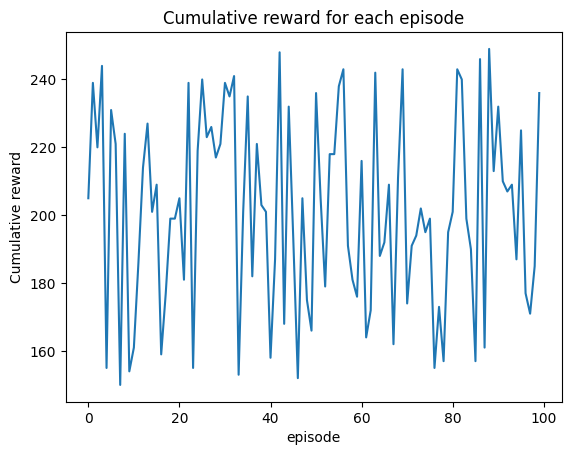

In [31]:
episode_results = np.random.randint(150, 250, size=100)
plt.plot(episode_results)
plt.title('Cumulative reward for each episode')
plt.ylabel('Cumulative reward')
plt.xlabel('episode')
plt.show()

Print the average reward over the 100 episodes.

In [32]:
print("Average cumulative reward:", episode_results.mean())
print("Is my agent good enough?", episode_results.mean() > 195)

Average cumulative reward: 201.53
Is my agent good enough? True


Graphical Evaluation using Q-table to decide best action for each state

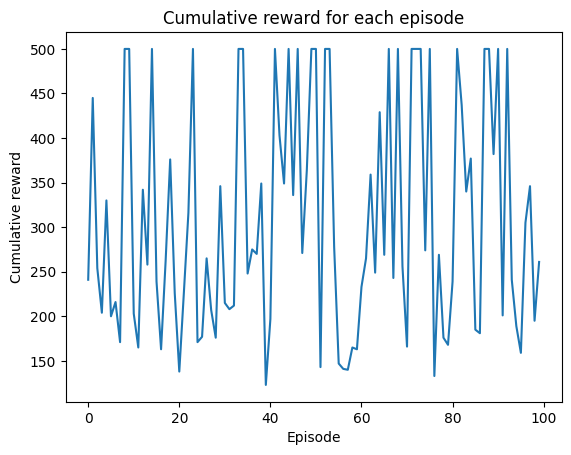

Average reward over 100 episodes: 308.41
Is my agent good enough? True


In [48]:
rewards = []
for episode in range(100):
    discrete_state = get_discrete_state(env.reset()[0])
    done = False
    episode_reward = 0
    while not done:
        action = np.argmax(q_table[discrete_state])
        new_state, reward, done, _ = env.step(action)
        episode_reward += reward
        discrete_state = get_discrete_state(new_state)
    rewards.append(episode_reward)

plt.plot(rewards)
plt.title('Cumulative reward for each episode')
plt.ylabel('Cumulative reward')
plt.xlabel('Episode')
plt.show()

print("Average reward over 100 episodes:", np.mean(rewards))
print("Is my agent good enough?", np.mean(rewards) > 195)

## Task 3: Render one episode played by the agent

Plug your agent (Q-Table) to the code below to obtain rendered result.

In [50]:
def trained_policy_agent(observation):
    discrete_state = get_discrete_state(observation)
    action = np.argmax(q_table[discrete_state])
    return action

In [59]:
env = RecordVideo(gym.make("CartPole-v1"), "./video")
observation = env.reset()
while True:
    env.render()
    #your agent goes here
    action = trained_policy_agent(observation)
    observation, reward, done, info = env.step(action)
    if done:
      break;
env.close()
show_video()

AttributeError: module 'numpy' has no attribute 'bool8'